In [6]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

import pickle
import json
import sys
import numpy.random as random

import time 
from src.online_prediction import OnlinePredictor
from src.models import createModel
from src.config import MetaConfig, ModelConfig

In [20]:
configPath = "config/config.json"
modelFolder = "model"
trafficDataFolder = "data/sender"
verbose = True

In [21]:
config = json.load(open(configPath))
name = config.get("NAME")
len_window = config.get("LEN_WINDOW")
dim_data =  len(config.get("CONTEXT_IDXS"))

In [23]:
csv_data = pd.read_csv(f"{trafficDataFolder}/traffic_dataset.csv")

metaConfig = MetaConfig.load(f"{modelFolder}/{name}_metaConfig.json")
modelConfig = ModelConfig.load(f"{modelFolder}/{name}_modelConfig.json")

metaConfig.display()
model, device = createModel(modelConfig)
model.load_checkpoint(f"{modelFolder}/{name}.pth")

MetaConfig:
  dim_data: 12
  len_window: 30
  len_source: 10
  len_target: 1
  train_ratio: 0.6
  data_augment: True
  Ts: 0.01


In [24]:
onlinePredictor = OnlinePredictor(model, metaConfig)

traffic_recieved_list = []
traffic_generated_list = []
traffic_predicted_list = []

# Initialize timing based on CSV Time column
count = 0
transmit_count = 0
N_count = 2000
base_csv_time = None
start_real_time = None
last_window_csv_time = None

while count < N_count:
    # Read current row
    csv_time = csv_data.iloc[count, 0]  # Time column
    transmission = csv_data.iloc[count, 1]  # Transmission Flags
    data_point = csv_data.iloc[count, 2:].values  # Payload data
    
    # Initialize base times on first row
    if base_csv_time is None:
        base_csv_time = csv_time
        start_real_time = time.time()
        last_window_csv_time = csv_time
    
    # ==================== transmitter timing ====================
    # Schedule based on CSV Time column (like sender.py)
    relative_seconds = csv_time - base_csv_time
    target_time = start_real_time + relative_seconds
    
    # Wait until target time
    while time.time() < target_time:
        time.sleep(0.001)  # Small sleep to avoid busy waiting
    
    count += 1
    
    # ==================== receiver ====================
    # Invoked upon receiving a new data point (only when transmission flag is 1)
    if int(transmission) == 1:
        onlinePredictor.receive_signal()
        transmit_count += 1
    
    # Invoked every len_window * Ts seconds based on CSV time
    if (csv_time - last_window_csv_time) >= (metaConfig.len_window * metaConfig.Ts):
        last_window_csv_time = csv_time
        traffic_generated_list.append(transmit_count)
        transmit_count = 0
        if onlinePredictor.is_ready():
            traffic_predicted, traffic_recieved = onlinePredictor.predict()
            traffic_predicted = np.round(traffic_predicted, 0).astype(int)
            traffic_predicted_list.append(traffic_predicted)
            traffic_recieved_list.append(traffic_recieved)

if verbose:
    print(f"Processed {count} rows")
    print(f"Generated {len(traffic_predicted_list)} predictions")

Processed 2000 rows
Generated 63 predictions


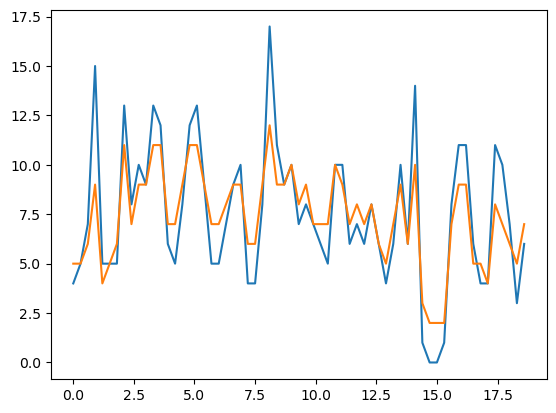

In [26]:
N_display = min(200, len(traffic_recieved_list))
timestamp = np.arange(len(traffic_recieved_list)) * metaConfig.Ts * metaConfig.len_window
plt.plot(timestamp[:N_display], traffic_recieved_list[:N_display])
plt.plot(timestamp[:N_display], traffic_predicted_list[:N_display])
plt.show()